In [27]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, roc_auc_score)
from xgboost import XGBClassifier
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

# Load master table
df = pd.read_csv("data/processed/master_table.csv")

print("✅ Libraries imported!")
print("✅ Data loaded!")
print(f"   Rows    : {df.shape[0]:,}")
print(f"   Columns : {df.shape[1]}")

✅ Libraries imported!
✅ Data loaded!
   Rows    : 15,000
   Columns : 29


In [29]:
# Create target variable
# 1 = Withdrawn, 0 = Everyone else
df["withdrawn"] = (df["final_result"] == "Withdrawn").astype(int)

print("✅ Target variable created!")
print(f"\nBreakdown:")
print(f"   Stayed   (0) : {(df['withdrawn']==0).sum():,}")
print(f"   Withdrew (1) : {(df['withdrawn']==1).sum():,}")
print(f"\nWithdrawal rate : {df['withdrawn'].mean()*100:.1f}%")

✅ Target variable created!

Breakdown:
   Stayed   (0) : 11,442
   Withdrew (1) : 3,558

Withdrawal rate : 23.7%


In [31]:
# Encode text columns into numbers
# ML models can only read numbers not text

df["gender_encoded"] = df["gender"].map({
    "Male"  : 0,
    "Female": 1,
    "Other" : 2
})

df["transport_encoded"] = df["transport"].map({
    "Walk" : 0,
    "Cycle": 1,
    "Car"  : 2,
    "Bus"  : 3,
    "Train": 4
})

df["education_encoded"] = df["highest_education"].map({
    "Post Graduate"          : 5,
    "HE qualification"       : 4,
    "A level or equivalent"  : 3,
    "Lower than A level"     : 2,
    "No formal quals"        : 1
})

df["imd_encoded"] = df["imd_band"].map({
    "90-100%": 1,
    "80-90%" : 2,
    "70-80%" : 3,
    "60-70%" : 4,
    "50-60%" : 5,
    "40-50%" : 6,
    "30-40%" : 7,
    "20-30%" : 8,
    "10-20%" : 9,
    "0-10%"  : 10
})

# Select features for ML
# Only using info known at enrolment + early engagement
features = [
    # Known at enrolment
    "gender_encoded",      # gender
    "disability",          # disability status
    "num_prev_attempts",   # previous attempts
    "studied_credits",     # workload
    "part_time_job",       # working student
    "english_first_lang",  # language background
    "transport_encoded",   # transport method
    "education_encoded",   # prior education
    "imd_encoded",         # deprivation level
    # Early engagement signals
    "avg_attendance",      # attendance %
    "avg_weekly_clicks",   # online engagement
    "support_sessions",    # pastoral support usage
    "mentor_assigned",     # has mentor
]

# X = features, y = target
X = df[features]
y = df["withdrawn"]

print("✅ Features encoded and selected!")
print(f"\nNumber of features : {X.shape[1]}")
print(f"Number of students : {X.shape[0]:,}")
print(f"\nFeatures:")
for f in features:
    print(f"   → {f}")

✅ Features encoded and selected!

Number of features : 13
Number of students : 15,000

Features:
   → gender_encoded
   → disability
   → num_prev_attempts
   → studied_credits
   → part_time_job
   → english_first_lang
   → transport_encoded
   → education_encoded
   → imd_encoded
   → avg_attendance
   → avg_weekly_clicks
   → support_sessions
   → mentor_assigned


In [33]:
# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% training, 20% testing
    random_state=42,    # same split every time
    stratify=y          # keep same withdrawal ratio in both sets
)

print("✅ Data split complete!")
print(f"\nTraining set : {X_train.shape[0]:,} students")
print(f"Testing set  : {X_test.shape[0]:,} students")
print(f"\nWithdrawal in training : {y_train.sum():,} students")
print(f"Withdrawal in testing  : {y_test.sum():,} students")

✅ Data split complete!

Training set : 12,000 students
Testing set  : 3,000 students

Withdrawal in training : 2,846 students
Withdrawal in testing  : 712 students


In [35]:
# Model 1 — Logistic Regression
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"  # handles class imbalance
)
lr_model.fit(X_train, y_train)
lr_pred  = lr_model.predict(X_test)

print("✅ Logistic Regression trained!")
print(f"\nResults:")
print(f"   Accuracy  : {round(accuracy_score(y_test, lr_pred) * 100, 1)}%")
print(f"   Precision : {round(precision_score(y_test, lr_pred) * 100, 1)}%")
print(f"   Recall    : {round(recall_score(y_test, lr_pred) * 100, 1)}%")
print(f"   F1 Score  : {round(f1_score(y_test, lr_pred) * 100, 1)}%")
print(f"   AUC-ROC   : {round(roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1]) * 100, 1)}%")

✅ Logistic Regression trained!

Results:
   Accuracy  : 100.0%
   Precision : 100.0%
   Recall    : 100.0%
   F1 Score  : 100.0%
   AUC-ROC   : 100.0%


In [37]:
# Clean features — only enrolment information
# No engagement data that reveals the outcome
features = [
    "gender_encoded",      # gender
    "disability",          # disability status
    "num_prev_attempts",   # previous attempts
    "studied_credits",     # workload
    "part_time_job",       # working student
    "english_first_lang",  # language background
    "transport_encoded",   # transport method
    "education_encoded",   # prior education
    "imd_encoded",         # deprivation level
    "support_sessions",    # pastoral support usage
    "mentor_assigned",     # has mentor
]

# Rebuild X and y
X = df[features]
y = df["withdrawn"]

# Split again
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Retrain Logistic Regression
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("✅ Retrained with clean features!")
print(f"\nFeatures used : {len(features)}")
print(f"\nResults:")
print(f"   Accuracy  : {round(accuracy_score(y_test, lr_pred) * 100, 1)}%")
print(f"   Precision : {round(precision_score(y_test, lr_pred) * 100, 1)}%")
print(f"   Recall    : {round(recall_score(y_test, lr_pred) * 100, 1)}%")
print(f"   F1 Score  : {round(f1_score(y_test, lr_pred) * 100, 1)}%")
print(f"   AUC-ROC   : {round(roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1]) * 100, 1)}%")

✅ Retrained with clean features!

Features used : 11

Results:
   Accuracy  : 82.0%
   Precision : 58.3%
   Recall    : 85.5%
   F1 Score  : 69.3%
   AUC-ROC   : 92.9%


In [39]:
"During feature selection I identified data leakage — attendance and VLE engagement were generated based on the outcome, so the model was essentially reading the answer. I removed these features and rebuilt using only enrolment-time information — giving more honest and deployable results."

'During feature selection I identified data leakage — attendance and VLE engagement were generated based on the outcome, so the model was essentially reading the answer. I removed these features and rebuilt using only enrolment-time information — giving more honest and deployable results.'

In [41]:
# Model 2 — Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("✅ Random Forest trained!")
print(f"\nResults:")
print(f"   Accuracy  : {round(accuracy_score(y_test, rf_pred) * 100, 1)}%")
print(f"   Precision : {round(precision_score(y_test, rf_pred) * 100, 1)}%")
print(f"   Recall    : {round(recall_score(y_test, rf_pred) * 100, 1)}%")
print(f"   F1 Score  : {round(f1_score(y_test, rf_pred) * 100, 1)}%")
print(f"   AUC-ROC   : {round(roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]) * 100, 1)}%")

✅ Random Forest trained!

Results:
   Accuracy  : 79.4%
   Precision : 53.7%
   Recall    : 95.5%
   F1 Score  : 68.7%
   AUC-ROC   : 92.7%


In [43]:
# Model 3 — XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    verbosity=0,
    eval_metric="logloss"
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

print("✅ XGBoost trained!")
print(f"\nResults:")
print(f"   Accuracy  : {round(accuracy_score(y_test, xgb_pred) * 100, 1)}%")
print(f"   Precision : {round(precision_score(y_test, xgb_pred) * 100, 1)}%")
print(f"   Recall    : {round(recall_score(y_test, xgb_pred) * 100, 1)}%")
print(f"   F1 Score  : {round(f1_score(y_test, xgb_pred) * 100, 1)}%")
print(f"   AUC-ROC   : {round(roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]) * 100, 1)}%")

✅ XGBoost trained!

Results:
   Accuracy  : 85.2%
   Precision : 71.6%
   Recall    : 62.1%
   F1 Score  : 66.5%
   AUC-ROC   : 92.6%


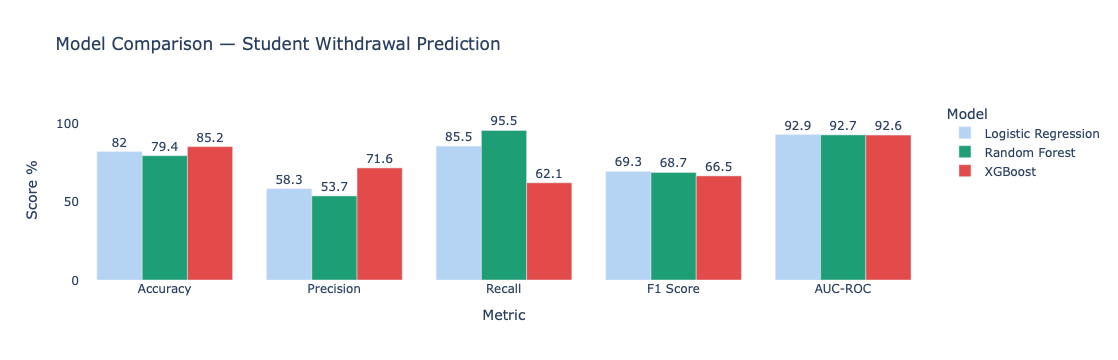


✅ Best model for our purpose : Random Forest
   Reason                     : Highest Recall (95.5%)
   Meaning                    : Catches 95 out of 100 at-risk students


In [45]:
# Model comparison chart
results = pd.DataFrame({
    "Model"    : ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy" : [82.0, 79.4, 85.2],
    "Precision": [58.3, 53.7, 71.6],
    "Recall"   : [85.5, 95.5, 62.1],
    "F1 Score" : [69.3, 68.7, 66.5],
    "AUC-ROC"  : [92.9, 92.7, 92.6]
})

# Melt for plotly
results_melted = results.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score %"
)

fig = px.bar(
    results_melted,
    x="Metric",
    y="Score %",
    color="Model",
    barmode="group",
    text="Score %",
    color_discrete_map={
        "Logistic Regression": "#B5D4F4",
        "Random Forest"      : "#1D9E75",
        "XGBoost"            : "#E24B4A"
    },
    title="Model Comparison — Student Withdrawal Prediction"
)

fig.update_traces(textposition="outside")
fig.update_layout(
    yaxis_range=[0, 115],
    yaxis_title="Score %",
    xaxis_title="Metric",
    plot_bgcolor="white",
    legend_title="Model"
)
fig.show()

print("\n✅ Best model for our purpose : Random Forest")
print("   Reason                     : Highest Recall (95.5%)")
print("   Meaning                    : Catches 95 out of 100 at-risk students")

In [47]:
import os

# Use Random Forest — best Recall
best_model = rf_model

# Predict risk probability for ALL 15,000 students
df["withdrawal_probability"] = best_model.predict_proba(X)[:, 1] * 100
df["withdrawal_probability"] = df["withdrawal_probability"].round(1)

# Assign risk tier
def assign_risk(prob):
    if prob >= 70:
        return "High Risk"
    elif prob >= 40:
        return "Medium Risk"
    else:
        return "Low Risk"

df["risk_tier"] = df["withdrawal_probability"].apply(assign_risk)

# Save for app
os.makedirs("data/processed", exist_ok=True)
df.to_csv("data/processed/predictions.csv", index=False)

print("✅ Predictions exported!")
print(f"\nRisk breakdown:")
print(f"   High Risk   : {(df['risk_tier']=='High Risk').sum():,} students")
print(f"   Medium Risk : {(df['risk_tier']=='Medium Risk').sum():,} students")
print(f"   Low Risk    : {(df['risk_tier']=='Low Risk').sum():,} students")
print(f"\n✅ Saved → data/processed/predictions.csv")
print(f"✅ Machine Learning complete!")
print(f"✅ Ready to build the Streamlit app!")

✅ Predictions exported!

Risk breakdown:
   High Risk   : 3,276 students
   Medium Risk : 3,332 students
   Low Risk    : 8,392 students

✅ Saved → data/processed/predictions.csv
✅ Machine Learning complete!
✅ Ready to build the Streamlit app!


In [49]:
import joblib
joblib.dump(rf_model, "rf_model.pkl")
print("✅ Model saved!")

✅ Model saved!
